## SWE - Synthesis - SOLUTION

We solved the same 1D bump-pulse step with multiple tools: NumPy, JAX, PyOMP,
nanobind, CuPy, CppJIT, and mpi4py. This notebook reads `timings.json` and compares them on first-call
compile cost and on a matched-float64 throughput sweep, from cache-resident to DRAM-resident sizes. It
closes with a summary table of programming models and limitations.

**SOLUTION**

### Table of Contents

1. [Read the timings](#sec1)
2. [First-call compile cost](#sec2)
3. [Matched-precision comparison across the memory hierarchy](#sec3)
4. [Programming models and limitations](#sec4)

### <a id="sec1"></a>1. Read the timings

Let's load every row from `timings.json` (written by notebooks 08-13). Each row
carries the warm wall-clock (`median_s`), the first-call cost where the
tool JIT-compiles (`cold_s`), the hardware and dtype it ran on, and the
max-diff against the float64 NumPy reference.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import swe_core

rows = swe_core.load_timings()
by_tool = {r["tool"]: r for r in rows}

# timings.json is written by notebooks 08 to 13
expected = ["numpy", "cupy", "cupy_fused", "jax", "jax_fp64", "pyomp",
            "nanobind", "cppjit_gpu_cub", "cppjit_gpu_raw", "mpi4py"]
missing = [t for t in expected if t not in by_tool]
if missing:
    raise SystemExit(
        "timings.json has no rows for: " + ", ".join(missing) + ". "
        "Run notebooks 08 through 13 first, then re-run this notebook."
    )

hdr = (f'{"stage":<24}{"tool":>18}{"hardware":>9}{"dtype":>9}'
       f'{"median_s":>11}{"cold_s":>9}{"max_diff":>12}')
print(hdr)
print("-" * len(hdr))
for r in rows:
    cold = r.get("cold_s", float("nan"))
    md = r.get("max_diff_vs_numpy")
    md_s = f"{md:.1e}" if md is not None else ("ref" if r["tool"] == "numpy" else "n/a")
    print(f'{r["stage"]:<24}{r["tool"]:>18}{r["hardware"]:>9}{r["dtype"]:>9}'
          f'{r["median_s"]:>11.4f}{cold:>9.3f}{md_s:>12}')

stage                                 tool hardware    dtype   median_s   cold_s    max_diff
--------------------------------------------------------------------------------------------
08_numpy                             numpy      cpu  float64     4.8083      nan         ref
09_jax                                 jax      gpu  float32     0.0058    1.800     1.2e-07
09_jax_fp64                       jax_fp64      gpu  float64     0.0109      nan     0.0e+00
10_pyomp                             pyomp      cpu  float64     0.0098    0.309     0.0e+00
11_nanobind                       nanobind      cpu  float64     0.0895      nan     1.1e-15
12_cppjit_gpu_cub           cppjit_gpu_cub      gpu  float64     0.0055    0.212     1.1e-15
12_cupy                               cupy      gpu  float64     0.0541    0.088     0.0e+00
12_cupy_fused                   cupy_fused      gpu  float64     0.0035    0.091     1.1e-15
12_cppjit_gpu_raw           cppjit_gpu_raw      gpu  float64     0.005

### <a id="sec2"></a>2. First-call compile cost

Cold time is the first call, where CuPy, JAX, PyOMP, and CppJIT pay a compile
cost before they execute. Warm is the steady-state median over repeated runs
at the canonical size from notebook 08. The JAX bars are its native float32 run;
the rest are float64. nanobind compiles at build time, not at first
call, so it has no cold bar.

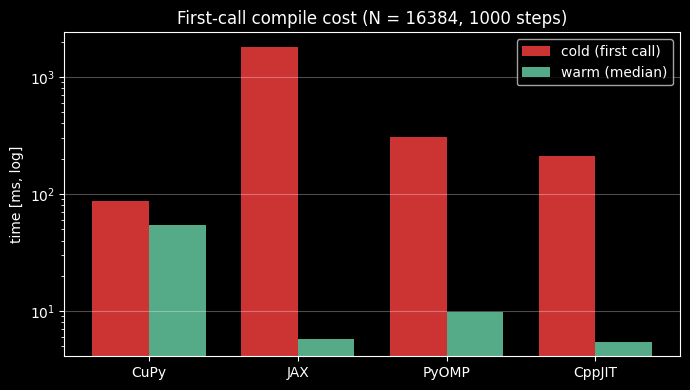

In [2]:
# Cold vs warm for the tools that JIT-compile on the first call.
jit = ["cupy", "jax", "pyomp", "cppjit_gpu_cub"]
jit_labels = {"cupy": "CuPy", "jax": "JAX", "pyomp": "PyOMP",
              "cppjit_gpu_cub": "CppJIT"}
swe_core.plot_cold_warm([jit_labels[t] for t in jit],
                        [by_tool[t]["cold_s"] for t in jit],
                        [by_tool[t]["median_s"] for t in jit],
                        "First-call compile cost (N = 16384, 1000 steps)")

### <a id="sec3"></a>3. Matched-precision comparison across the memory hierarchy

This is the primary benchmark: every tool runs float64 over the sizes
notebook 08 fixed for this machine. The working set is six fp64 arrays,
48 B per cell, so the sweep runs from cache into DRAM on both devices.
Throughput is the solve loop for one call from Python; step counts shrink
with `N`.

The fused GPU kernels are bandwidth-bound at these sizes, so a float32
solve gains exactly the bytes it saves.

The plot's cache boundaries use this 48 B model. NumPy's temporaries double
its bytes per cell, so its curve leaves cache earlier. PyOMP's fused kernel
streams only the four state arrays, so its curve leaves later. The GPU curve
runs flat through its L2 boundary: a working set that fits in L2 measures no
faster than one that does not.

          N         NumPy  CuPy drop-in    CuPy fused           JAX    CppJIT CUB    CppJIT raw         PyOMP        mpi4py      nanobind   Mcells/s
    262,144            69           737         37760          9773         28150         28597          7690          2112           172
  1,048,576            63          2986         56535         19125         36478         40003         13744          1395           681
  4,194,304            38          3642         58102         18211         35760         37115         19111           948          2189
 16,777,216            31          4089         59204         19637         37701         38672         20774           590          3153
 67,108,864             -          4223         56324         20317         38298         38708         10229           550          2583


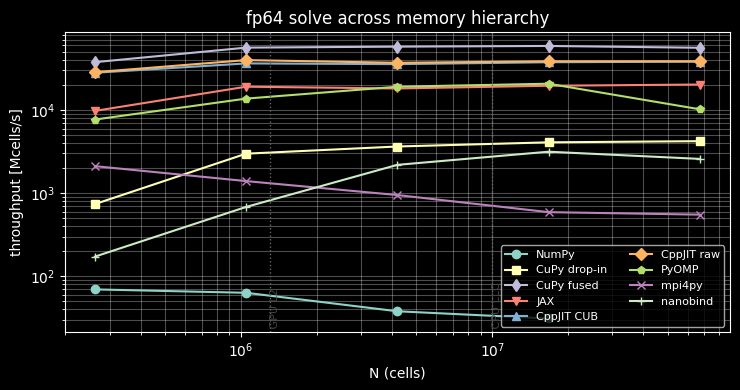

In [3]:
# Matched-precision (float64) comparison, read from timings.json.
import cupy as cp

NAMES = {'08_numpy': 'NumPy', '12_cupy': 'CuPy drop-in',
         '12_cupy_fused': 'CuPy fused', '09_jax_fp64': 'JAX',
         '12_cppjit_gpu_cub': 'CppJIT CUB', '12_cppjit_gpu_raw': 'CppJIT raw',
         '10_pyomp': 'PyOMP', '13_mpi4py': 'mpi4py',
         '11_nanobind': 'nanobind'}
by_stage = {r['stage']: r for r in rows if 'sweep' in r}
swe_core.require_stages(by_stage, NAMES)

# Each tool carries its own (N, rate) pairs, since a slow tool stops earlier.
Ns, rate = swe_core.sweep_series(by_stage, NAMES)

# Where the fp64 working set outgrows each device's last-level cache.
bpc = swe_core.working_set_bytes(1)
llc = swe_core.llc_total_mib()
l2  = swe_core.device_l2_mib()
realms = ([(l2 * 2**20 / bpc, 'GPU L2')] if l2 else []) + \
         ([(llc * 2**20 / bpc, 'CPU LLC')] if llc else [])
swe_core.plot_rate_sweep(Ns, rate, 'N (cells)',
                         'fp64 solve across memory hierarchy',
                         boundaries=realms)

#### Where end-to-end time is spent

A wall-clock number cannot say where the time went. The bars below come from
Nsight Systems: one warm call per tool, with a capture range so the report
covers that call and nothing around it. GPU kernels and memory copies are what
the profiler measured. The host bar is the remainder, which is Python
assembling launches and any wait the device did not fill.

Kernels dominate every path here, so what separates them is work on the
device, not host overhead. JAX is the exception on copies: its scan carries
state between steps as device-to-device transfers.

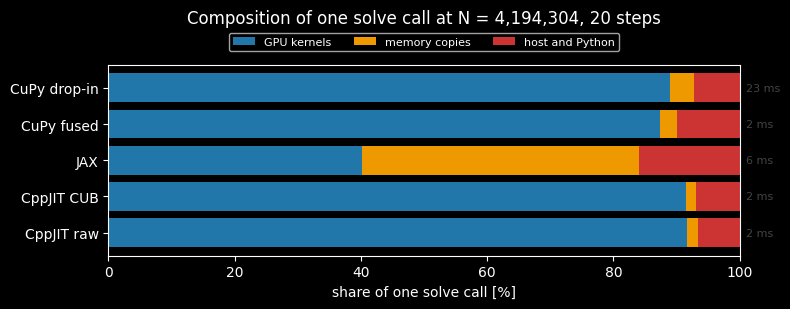

In [4]:
# Composition of one profiled solve call, recorded by each tool's own
# notebook (swe_core.nsys_breakdown + save_breakdown).
BSTAGES = ['12_cupy', '12_cupy_fused', '09_jax_fp64',
           '12_cppjit_gpu_cub', '12_cppjit_gpu_raw']
swe_core.require_stages(by_stage, BSTAGES, key='breakdown')

PARTS = [('kernel_s', 'GPU kernels', '#27a'),
         ('memcpy_s', 'memory copies', '#e90'),
         ('host_s', 'host and Python', '#c33')]
fig, ax = plt.subplots(figsize=(8, 3.2))
ys, left = np.arange(len(BSTAGES)), np.zeros(len(BSTAGES))
for key, lbl, color in PARTS:
    frac = np.array([by_stage[s]['breakdown'][key]
                     / by_stage[s]['breakdown']['total_s']
                     for s in BSTAGES]) * 100
    ax.barh(ys, frac, left=left, color=color, label=lbl)
    left += frac
ax.set_yticks(ys); ax.set_yticklabels([NAMES[s] for s in BSTAGES])
ax.invert_yaxis(); ax.set_xlim(0, 100)
ax.set_xlabel('share of one solve call [%]')
bd0 = by_stage[BSTAGES[0]]['breakdown']
ax.set_title(f"Composition of one solve call at N = {bd0['n']:,}, {bd0['steps']} steps", pad=30)
for s, y in zip(BSTAGES, ys):
    ax.text(101, y, f"{by_stage[s]['breakdown']['total_s'] * 1e3:,.0f} ms",
            va='center', fontsize=8, color='#444')
ax.legend(ncols=4, fontsize=8, loc='lower center', bbox_to_anchor=(0.5, 1.04))
plt.tight_layout(); plt.show()

### <a id="sec4"></a>4. Programming models and limitations

The plots rank by throughput. The table below is the qualitative counterpart: the programming model each tool exposes, and where that model stops.

| Tool | Programming model | Limitation |
|---|---|---|
| **NumPy** | Array programming on the host | Single-threaded, no GPU |
| **CuPy** | Array programming on the device, NumPy API | One kernel per elementwise op and Python in the loop, unless hand-fused via `ElementwiseKernel` |
| **JAX** | Pure functions traced and compiled to one device program; autodiff | Shape-rigidity: each new input shape pays a fresh XLA compile; float32 is the default and float64 pays the bandwidth its extra bytes cost |
| **PyOMP** | OpenMP directives inside a JIT-compiled Python function | Scaling stops at physical cores; scalar per-core rate is arithmetic bound at cache-resident sizes |
| **mpi4py** | Explicit messages between independent processes | Per-step fixed costs dominate as slabs shrink; one NumPy rank per core on a single node |
| **nanobind** | Hand-written bindings to a compiled C++ extension | Build-system glue and FFI cost, plus a recompile-on-edit cycle |
| **CppJIT** | C++ and CUDA compiled into the live session, with bindings generated automatically | First-call compile cost, high memory utilisation and parsing cost (JIT overhead) with large translation units |